# 시나리오
- ai 관련 교육상담을 하는 챗봇을 구성한다.
- 최근 정부에서 "ai캠퍼스"라는 교육사업을 추진 중
- 해당 사업에 대한 공고문(pdf) 활용
- 해당 사업에 맞는 과정 홍보 페이지
  - https://smhrd.or.kr/course/aic_network/

## 학습내용
-  Multi-Source RAG 실습 (PDF와 웹페이지 retriver 정보 결합)
- Query Transformation 실습
   - ex) AI캠퍼스 교육과정 어때? -> 사용자는 보통 질문을 축약해서 하는 편. -> 답변이 제대로 나오지 않음<br> => llm을 활용해 의도를 파악, 디테일 파악하게
   - LLM에 변경요청 -> AI캠퍼스의 사업목표, 교육과정종류, 시수, 커리큘럼 등을 알려줘 <br>
   (검색기에 유사도 비교가 용이하도록 질문을 변환)  

# 환경변수 설정

In [ ]:
# open AI key 등록
import os
OPENAI_API_KEY="본인의 OpenAI API 키를 입력하세요"

# 현재 노트북 커널에 환경변수 등록
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY

# LangSmith API key등록
LANGSMITH_TRACING="true"
LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
LANGSMITH_API_KEY="본인의 LangSmith API 키를 입력하세요"
LANGSMITH_PROJECT="langchain0422"

# 현재 노트북 커널에 환경변수 등록
os.environ['LANGSMITH_TRACING']=LANGSMITH_TRACING
os.environ['LANGSMITH_ENDPOINT']=LANGSMITH_ENDPOINT
os.environ['LANGSMITH_API_KEY']=LANGSMITH_API_KEY
os.environ['LANGSMITH_PROJECT']=LANGSMITH_PROJECT

In [ ]:
# 라이브러리 설치
!pip install langchain langchain-openai langchain-community faiss-cpu pypdf chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/18

## 1. Query Transformation

In [ ]:
# [RAG 관련도구]
# 재귀적 텍스트 분할 도구
from langchain_text_splitters import RecursiveCharacterTextSplitter
# 임베딩도구
from langchain_openai import OpenAIEmbeddings
# 벡터데이터베이스 도구
from langchain_community.vectorstores import FAISS
# 문서 도구
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader

# [Chain 구성도구]
# LLM 생성도구
from langchain.chat_models import init_chat_model
# 프롬프트 템플릿
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
# 출력파서 도구
from langchain_core.output_parsers import JsonOutputParser,StrOutputParser
# 구조생성용 Runnable 도구
from langchain_core.runnables import RunnablePassthrough, RunnableBranch, RunnableParallel, RunnableLambda

In [ ]:
QT_template = ChatPromptTemplate.from_template('''
  너는 사용자의 query를 retriver가 더 잘 검색하도록 최적화하는 역할이야.

  - 수행내용
    1. 아래 query를 기반으로 사용자의 질문 의도를 추출
    2. 사용자 질문을 깔끔하고 정돈된 질문으로 변환
    3. 사용자의 질문을 다양한 관점으로 확장해서 3가지 정도로 늘리기

    - query : {query}

    - 출력형식
      아래 key 값을 이용해서 파싱가능한 JSON 구조로 만들어줘

      key :
        - user_intent
        - normalize_query
        - expanded_query
''')

# 1. 아래 query를 기반으로 사용자의 질문 의도를 추출 -> user_intent
# 2. 사용자 질문을 깔끔하고 정돈된 질문으로 변환 -> normalize_query
# 3. 사용자의 질문을 다양한 관점으로 확장해서 3가지 정도로 늘리기 -> expanded_query

In [ ]:
# 체인구성하기

# 모델생성
llm_4o_mini = init_chat_model("openai:gpt-4o-mini", max_tokens=1024)
# 파서생성
jsonParser = JsonOutputParser()

# QT_chain : 사용자 query를 분석하여 의도추출, 정제, 확장된 검색용 질의(JSON)로 변환하는 체인
QT_chain = QT_template | llm_4o_mini | jsonParser

In [ ]:
# q1
QT_chain.invoke("에이아이 캠퍼스 교육과정 어때?")
# 'expanded_query' 확장된 질문을 바탕으로 질문을 하게 되면 답변의 정확도를 높이게

{'user_intent': '에이아이 캠퍼스의 교육과정에 대한 평가 및 정보 요청',
 'normalize_query': '에이아이 캠퍼스의 교육과정은 어떤가요?',
 'expanded_query': ['에이아이 캠퍼스에서 제공하는 교육과정의 내용은 어떤지 궁금합니다.',
  '에이아이 캠퍼스의 교육과정에 대한 수강생들의 후기나 평가는 어떤가요?',
  '에이아이 캠퍼스의 교육과정을 다른 교육기관과 비교했을 때 장단점은 무엇인가요?']}

In [ ]:
# q2
QT_chain.invoke("ai 교육 추천해줘")

{'user_intent': 'AI 교육 프로그램이나 자료를 추천받고 싶다.',
 'normalize_query': 'AI 교육 프로그램을 추천해 주세요.',
 'expanded_query': ['추천할 만한 AI 교육 과정이나 플랫폼이 있나요?',
  '초보자를 위한 AI 교육 자료를 소개해 줄 수 있나요?',
  'AI 분야에서 유용한 교육 콘텐츠나 워크숍이 있으면 알려주세요.']}

In [ ]:
# q3
QT_chain.invoke("ai캠퍼스 과정 빡세?")
# "빡세" 표현에 대해 일반적인 단어로 풀어서 질문

{'user_intent': 'AI 캠퍼스 과정의 난이도나 강도를 묻는 질문',
 'normalize_query': 'AI 캠퍼스 과정은 어렵나요?',
 'expanded_query': ['AI 캠퍼스 과정은 얼마나 힘든가요?',
  'AI 캠퍼스 과정의 난이도는 어떤가요?',
  'AI 캠퍼스 과정 수업은 힘든가요?']}

## 2. 파일기반 retriver 구성하기

In [ ]:
# 파일로더 생성
loader = PyPDFLoader("/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/260107 K-디지털 트레이닝 AI 캠퍼스 운영(인적자원개발과).pdf")

# 데이터로딩
documents = loader.load()

In [ ]:
len(documents)

4

In [ ]:
type(documents)

list

In [ ]:
documents

[Document(metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2022 12.0.0.4204', 'creationdate': '2026-01-06T14:12:03+09:00', 'author': 'Moel', 'moddate': '2026-01-06T14:12:03+09:00', 'pdfversion': '1.4', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/260107 K-디지털 트레이닝 AI 캠퍼스 운영(인적자원개발과).pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}, page_content='고용노동부보도자료보도시점2026. 1. 7.(수) 12:00(2026. 1. 8.(목) 조간)고용노동부, K-디지털 트레이닝 ｢AI 캠퍼스｣로 AI 전문인력 1만 명 양성- 현장 수요 높은 인공지능(AI) 엔지니어, 인공지능(AI) 앱 개발자 집중 양성 - ‘AI 캠퍼스’ 참여기관에는 훈련과정 설계, 운영 자율성을 부여  - 비수도권 훈련생에게는 최대 월 60만 원 훈련수당 지급  고용노동부(장관 김영훈)와 한국기술교육대 직업능력심사평가원은 2026년부터 인공지능(이하, ‘AI’) 전문인력 양성을 위한 K–디지털 트레이닝(이하, ‘KDT’) ‘AI 캠퍼스’를 운영한다고 밝혔다.   * KDT AI 캠퍼스는 지난 12.18.(목) 제2차 과학기술관계장관회의에서 발표한 ｢노동시장 AI 인재양성 추진방안｣의 일환임  노동부는 올해부터 도입하는 KDT ‘AI 캠퍼스’ 과정을 통해, 연간 약 1,300억 원의 예산을 투입해 1만여 명의 AI 전문 인력을 양성할 계획이다. 이는 기업들이 미래 경쟁력 확보를 위해 AI 도입을 본격화하고 있음에도 전문인력 부족 등으로 어려움을 겪고 있는 점을 고려해 AI 전환을 성공적으로 이끌 청

In [ ]:
# chunk 단위로 분할
# pdf_splitter -> pdf파일 기반 텍스트 분할기
pdf_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""],
    chunk_size = 500,
    chunk_overlap = 100
)

In [ ]:
pdf_chunk =pdf_splitter.split_documents(documents)

In [ ]:
len(pdf_chunk)

12

In [ ]:
# 임베딩 및 인덱싱
vec_db = FAISS.from_documents(
    documents = pdf_chunk,          # 임베딩 할 벡터
    embedding = OpenAIEmbeddings()  # 임베딩 도구 연결
)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************TIQA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [ ]:
# 사용자 질문과 유사한 청크 2개를 찾는 검색기 생성
pdf_retriver = vec_db.as_retriever(search_kwargs={'k':2})

NameError: name 'vec_db' is not defined

In [ ]:
# 테스트
pdf_retriver.invoke('AI 캠퍼스 과정은 얼마나 힘든가요?')

[Document(id='0c960382-45fc-4f2c-b97b-a641a3a5be4a', metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2022 12.0.0.4204', 'creationdate': '2026-01-06T14:12:03+09:00', 'author': 'Moel', 'moddate': '2026-01-06T14:12:03+09:00', 'pdfversion': '1.4', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/260107 K-디지털 트레이닝 AI 캠퍼스 운영(인적자원개발과).pdf', 'total_pages': 4, 'page': 2, 'page_label': '3'}, page_content='‘AI 캠퍼스’에 참여하는 훈련생들에 대해서는 출석률에 따라 매월 훈련수당을 지급한다. 훈련기관 소재지 기준으로 수도권 훈련생들에게는 월 40만 원, 비수도권 훈련생들에게는 월 60만 원을 지급하며, 인구감소지역 훈련생들에게는 월 80만 원을 지급한다.  고용노동부 편도인 직업능력정책국장은 “AI 전환은 중견․중소기업의 경쟁력을 좌우할 핵심 요인으로 이러한 전환을 뒷받침할 AI 전문인력 양성에 정부가 선제적으로 나서야 한다는 것이 전문가들의 공통된 의견이다.”라고 언급하며, “AI 캠퍼스가 이런 역할을 충실히 담당할 수 있도록 체계적으로 설계하고 운영해 나가겠다.”라고 밝혔다. [붙임] AI 캠퍼스 양성 목표 직종(직무)[별첨] 2026년도 K-디지털트레이닝 AI 캠퍼스 심사평가 계획 공고      (2026. 1. 8. 직업능력심사평가원 누리집, www.ksqa.or.kr에서 제공 예정)담당 부서고용노동부 직업능력정책국책임자과  장'),
 Document(id='f0d1937f-6206-4ef4-bc3f-726404dcfc63', meta

In [ ]:
# 테스트
pdf_retriver.invoke('에이아이 캠퍼스에서 제공하는 교육과정의 내용은 어떤지 궁금합니다.')

[Document(id='f0d1937f-6206-4ef4-bc3f-726404dcfc63', metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2022 12.0.0.4204', 'creationdate': '2026-01-06T14:12:03+09:00', 'author': 'Moel', 'moddate': '2026-01-06T14:12:03+09:00', 'pdfversion': '1.4', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/260107 K-디지털 트레이닝 AI 캠퍼스 운영(인적자원개발과).pdf', 'total_pages': 4, 'page': 3, 'page_label': '4'}, page_content='붙임 AI 캠퍼스 양성 목표 직종(직무) 직군분류 (예시 직종/직무) 직무정의① AI 엔지니어(AI Engineer)"어 떻 게  구 현 하 는 가?" 연구자가 밝혀낸 원리를 바탕으로, 실 제  사 용 자 가  쓸 수 있는 안정적인 서비스를 구축하고 운영'),
 Document(id='e9579b2c-617c-413d-981a-ee0d963d8c4d', metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2022 12.0.0.4204', 'creationdate': '2026-01-06T14:12:03+09:00', 'author': 'Moel', 'moddate': '2026-01-06T14:12:03+09:00', 'pdfversion': '1.4', 'source': '/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용/data/260107 K-디지털 트레이닝 AI 캠퍼스 운영(인적자ᄋ

## 3. 웹페이지기반 retriver 구성하기
- 기본 WebBaseLoader는 정적페이지는 잘 불러온다.
- 동적페이지를 불러오려면 외부도구나 selenium을 활용하는것이 효과적이다.

In [ ]:
# 앞쪽에서 selenium을 통해 웹 문서의 text를 추출했다는 가정하에 진행
text1 = '''
6개월 과정960시간오프라인
파이썬과 AI수학
- 파이썬 분석/시각화, 선형대수, 확률, 통계

컴퓨터 비전
- 영상처리, 객체탐지/인식, 동작인식, 얼굴인식, 영역분할

머신러닝/딥러닝
- 지도/비지도학습, 평가지표, 신경망, CNN, RNN, Transformer, LMM/VLM/VLA

로봇 운동학
- 3차원공간 이해, 좌표계 변환, 자유도, FK/IK 해석, 로봇 움직임 제어, PID

ROS2과 SLAM
- ROS2, 거리 및 IMU 센서, 점군 데이터 처리, SLAM, Navigation

가상 로봇 설계
- URDF/SDF기반 설계, 가상센서, 가상 로봇 제어

가상 로봇 제어
- 맵핑, 장애물 회피, 복구행동, 경로계획, 행동결정, 로봇팔, 다중로봇, 자율주행

현실 로봇 제어
- ROS brigde, 카메라/Lidar 연동, 모터 제어, 자율주행

배포 서비스 구현
- Streamlit/FastAPI

AI 서비스 설계
- AI 웹 서비스 기술 (HTML/CSS, JS, Node.js. React.js)
'''

In [ ]:
from importlib import metadata
doc1 = Document(
    page_content= text1,
    metadata = {"source" : "https://smhrd.or.kr/course/aic_network/"}
)

In [ ]:
doc1

Document(metadata={'source': 'https://smhrd.or.kr/course/aic_network/'}, page_content='\n6개월 과정960시간오프라인\n파이썬과 AI수학\n- 파이썬 분석/시각화, 선형대수, 확률, 통계\n\n컴퓨터 비전\n- 영상처리, 객체탐지/인식, 동작인식, 얼굴인식, 영역분할\n\n머신러닝/딥러닝\n- 지도/비지도학습, 평가지표, 신경망, CNN, RNN, Transformer, LMM/VLM/VLA\n\n로봇 운동학\n- 3차원공간 이해, 좌표계 변환, 자유도, FK/IK 해석, 로봇 움직임 제어, PID\n\nROS2과 SLAM\n- ROS2, 거리 및 IMU 센서, 점군 데이터 처리, SLAM, Navigation\n\n가상 로봇 설계\n- URDF/SDF기반 설계, 가상센서, 가상 로봇 제어\n\n가상 로봇 제어\n- 맵핑, 장애물 회피, 복구행동, 경로계획, 행동결정, 로봇팔, 다중로봇, 자율주행\n\n현실 로봇 제어\n- ROS brigde, 카메라/Lidar 연동, 모터 제어, 자율주행\n\n배포 서비스 구현\n- Streamlit/FastAPI\n\nAI 서비스 설계\n- AI 웹 서비스 기술 (HTML/CSS, JS, Node.js. React.js)\n')

In [ ]:
text2 = '''
6개월 과정960시간오프라인
파이썬과 AI수학
- 파이썬 분석/시각화, 선형대수, 확률, 통계

데이터 수집/전처리
- 크롤링, 데이터 구조 (JSON, XML, CSV 등)

머신러닝/딥러닝
- 지도/비지도학습, 평가지표, 신경망, CNN, RNN, Transformer, LMM/VLM/VLA

컴퓨터 비전
- 영상처리, 객체탐지/인식, 동작인식, 얼굴인식, 영역분할

텍스트마이닝
- 텍스트 전처리, 임베딩, 기본 모델 실습, Transformer, 모델 활용 실습

음성데이터 / 시계열 데이터
- 텍스트 전처리, 임베딩, 기본 모델 실습, Transformer, 모델 활용 실습

LangChain
- 프롬프트, 템플릿, 체인 생성/연결, 메모리, RAG, 고급 RAG

AI Agent
- LangServe, LangSmith, Ollama, LangGraph

Vision Agent
- 종류, 구현실습, LangGraph 기반 구현

배포 서비스
- Streamlit / FastAPI / n8n

AI 서비스 설계
- AI 웹 서비스 기술(HTML/CSS, JS, Node.js, React.js)
'''

In [ ]:
doc2 = Document(
    page_content= text2,
    metadata = {"source" : "https://smhrd.or.kr/course/aic_network/"}
)

In [ ]:
text3 = '''
6개월 과정960시간오프라인
헬스케어 AI와 파이썬
- 헬스케어 산업/기술/현황, 파이썬 분석/시각화, 선형대수, 확률, 통계

Java
- 정보공학, 환경설정, 연산자, 제어문, 배열, OOP, 예외처리, I/O, 쓰레드

JSP/Spring
- HTML, CSS, JS, JSP, Spring, Spring AI

데이터베이스
- 데이터베이스 개론, RDBMS실습, NoSQL

데이터 수집/전처리
- 헬스케어 데이터 크롤링, 데이터 구조 (JSON, XML, CSV 등)

머신러닝/딥러닝
- 지도/비지도학습, 평가지표, 신경망, CNN, RNN, Transformer, LMM/VLM/VLA

컴퓨터 비전
- 영상처리, 객체탐지/인식, 동작인식, 얼굴인식, 영역분할

텍스트마이닝
- 텍스트 전처리, 임베딩, 기본 모델 실습, Transformer, 모델 활용 실습

LangChain
- 프롬프트, 템플릿, 체인 생성 /연결, 메모리, RAG, 고급 RAG

n8n
- 노드, 워크플로우 설계, 인증, AI 자동화, MCP
'''

In [ ]:
doc3 = Document(
    page_content= text3,
    metadata = {"source" : "https://smhrd.or.kr/course/aic_network/"}
)

In [ ]:
text4 = '''
6개월 과정960시간오프라인
지역산업 AI 비즈니스 이해
- 지역특화산업/현황, AI 서비스 기획, 비즈니스브리프, 고객 여정맵, 시장조사, KPI

고객경험 도메인 데이터 설계
- 경험데이터 분석, DCX개념에 따른 고객맞춤형 서비스 모델 이해, 아이디어 토론 및 공유

X+AI와 파이썬
- 지역도메인AI현황 분석, 파이썬 분석/시각화, 선형대수, 확률, 통계

데이터베이스
- 데이터베이스 개론, RDBMS실습, NoSQL

통계적분석기반 도메인 데이터 이해
- 실데이터 분석, 시나리오 정의, 인사이트 도출 및 솔루션 설계

고객경험 도메인 데이터 수집
- HTML, CSS, Web Crawling, 고객경험 데이터 수집/분석/ 서비스 기획 실습. 수집된 데이터 활용 방안 수립

디지털 맥락 파악 및 고객 감성분석
- 머신러닝, 텍스트마이닝, 시각화, 감정분석, Word2Vec, 키워드 추출

X+AI 비지니스 가치 설계
- 페르소나정의, ActionMap 작성, 기회영역 분석, 고객경험 디자인수행, AI기술, BMC, AI 윤리

AI활용 고객경험 분석
- 딥러닝, 컴퓨터 비전, 텍스트마이닝, 챗봇, 음성처리

도메인데이터 분석기반 MVP 설계
- 프로젝트관리, KPI/OKR, 사용자 피드백, UX, 서비스 블루프린트, PoC, 노코드 AI 도구, 프로토타입 제작
'''

In [ ]:
doc4 = Document(
    page_content= text4,
    metadata = {"source" : "https://smhrd.or.kr/course/aic_network/"}
)

In [ ]:
# 4개의 문서를 하나의 리스트에 추가하여 웹 청크로 구성
# doc 1개당 하나의 과정이기 때문에 doc을 chunk 할 필요 없음
web_chunk = [doc1,doc2,doc3,doc4]

In [ ]:
web_chunk

[Document(metadata={'source': 'https://smhrd.or.kr/course/aic_network/'}, page_content='\n6개월 과정960시간오프라인\n파이썬과 AI수학\n- 파이썬 분석/시각화, 선형대수, 확률, 통계\n\n컴퓨터 비전\n- 영상처리, 객체탐지/인식, 동작인식, 얼굴인식, 영역분할\n\n머신러닝/딥러닝\n- 지도/비지도학습, 평가지표, 신경망, CNN, RNN, Transformer, LMM/VLM/VLA\n\n로봇 운동학\n- 3차원공간 이해, 좌표계 변환, 자유도, FK/IK 해석, 로봇 움직임 제어, PID\n\nROS2과 SLAM\n- ROS2, 거리 및 IMU 센서, 점군 데이터 처리, SLAM, Navigation\n\n가상 로봇 설계\n- URDF/SDF기반 설계, 가상센서, 가상 로봇 제어\n\n가상 로봇 제어\n- 맵핑, 장애물 회피, 복구행동, 경로계획, 행동결정, 로봇팔, 다중로봇, 자율주행\n\n현실 로봇 제어\n- ROS brigde, 카메라/Lidar 연동, 모터 제어, 자율주행\n\n배포 서비스 구현\n- Streamlit/FastAPI\n\nAI 서비스 설계\n- AI 웹 서비스 기술 (HTML/CSS, JS, Node.js. React.js)\n'),
 Document(metadata={'source': 'https://smhrd.or.kr/course/aic_network/'}, page_content='\n6개월 과정960시간오프라인\n파이썬과 AI수학\n- 파이썬 분석/시각화, 선형대수, 확률, 통계\n\n데이터 수집/전처리\n- 크롤링, 데이터 구조 (JSON, XML, CSV 등)\n\n머신러닝/딥러닝\n- 지도/비지도학습, 평가지표, 신경망, CNN, RNN, Transformer, LMM/VLM/VLA\n\n컴퓨터 비전\n- 영상처리, 객체탐지/인식, 동작인식, 얼굴인식, 영역분할\n\n텍스트마이닝\n- 텍스트 전처리, 임베딩, 기본 모델 실습, Transfor

In [ ]:
# 임베딩 및 인덱싱
vec_db2 = FAISS.from_documents(
    documents = web_chunk,          # 임베딩 할 벡터
    embedding = OpenAIEmbeddings()  # 임베딩 도구 연결
)

In [ ]:
# 사용자 질문과 유사한 청크 1개를 찾는 검색기 생성
# -> 4가지 과정 중 1개만 찾도록
web_retriver = vec_db2.as_retriever(search_kwargs={'k':1})

## 4. 교육과정 챗봇 구성하기
- 사용자의 질문에 커리큘럼 내용이 있으면 web_retriver가 수행되도록 branch 구성

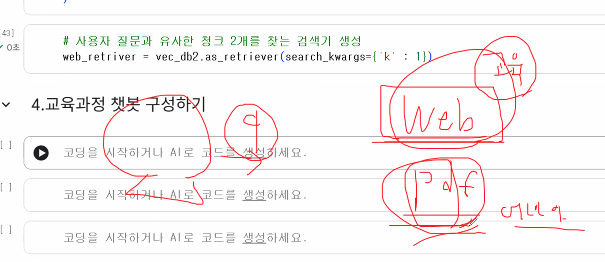

- RunnableBranch로 분할해서 갈건지 RunnableParallel로 병렬 식으로 갈건지 -> 선택

In [ ]:
extract_info = ChatPromptTemplate.from_template('''
  아래 query 데이터에서 사용자가 과정에 대한 질문을 하는지 파악하고
  과정 커리큘럼에 대한 질문이라면 특정 과정을 문의하는지 파악해서 알려줘

  출력형식은 아래와 같이 이렇게 JSON 형태로 만들어줘. JSON 파싱이 가능하도록 꼭 포맷 지켜줘.

  과정문의 : True, 과정타입 : 헬스케어

  만약 과정 타입이 정보에 없다면 없음이라고 표기해

  query : {query}
''')

In [ ]:
# 체인구성
test_chain = {"query" : QT_chain} | extract_info | llm_4o_mini | JsonOutputParser()

In [ ]:
test_chain.invoke("ai캠퍼스의 교육과정에는 어떤 과목들이 포함되어 있나요?")

{'과정문의': True, '과정타입': '없음'}

In [ ]:
test_chain.invoke("헬스케어 교육 듣고 싶어요")

{'과정문의': True, '과정타입': '헬스케어'}

In [ ]:
test_chain.invoke("ai캠퍼스 사업이 뭔가요?")

{'과정문의': False, '과정타입': '없음'}

#### 구조변경하기

In [ ]:
# 정보추출 체인
extract_chain = extract_info | llm_4o_mini | JsonOutputParser()

In [ ]:
test_chain2 = {"query" : QT_chain} | RunnableParallel(
    info = extract_chain,
    QT_result = RunnablePassthrough()
)

In [ ]:
test_chain2.invoke("AI캠퍼스 사업이 뭐야?")

{'info': {'과정문의': False, '과정타입': '없음'},
 'QT_result': {'query': {'user_intent': 'AI캠퍼스 사업의 개요와 목적을 이해하고자 함',
   'normalize_query': 'AI캠퍼스 사업에 대해 설명해줄 수 있나요?',
   'expanded_query': ['AI캠퍼스 사업의 주요 목표와 활동은 무엇인가요?',
    'AI캠퍼스 사업의 정의와 그 중요성에 대해 알고 싶습니다.',
    'AI캠퍼스 사업이 제공하는 서비스와 혜택은 무엇인가요?']}}}

In [ ]:
# 브렌치 추가하기
web_chain = RunnableParallel(
    context = RunnableLambda(lambda x : x['QT_result']) | RunnableLambda( lambda x : PromptTemplate.from_template('{query}').invoke(x).text) | web_retriver,
    question = RunnableLambda(lambda x : x['QT_result']['query'])
)

pdf_chain = RunnableParallel(
    context = RunnableLambda(lambda x : x['QT_result'])| RunnableLambda( lambda x : PromptTemplate.from_template('{query}').invoke(x).text) | pdf_retriver,
    question = RunnableLambda(lambda x : x['QT_result']['query'])
)

# 챗봇용 템플릿 생성
chatbot_template = ChatPromptTemplate.from_messages([
    ('system','너는 교육과정 응답을 하는 챗봇이야. 아래 context 내용과 question을 기반으로 답변해줘'),
    ('system', 'context : {context}'),
    ('human', 'question : {question}')
])

final_chain = test_chain2 | RunnableBranch(
                      (lambda x : x['info']['과정문의'] == True, lambda x : web_chain),
                       lambda x : pdf_chain
              ) | chatbot_template | llm_4o_mini | StrOutputParser()

In [ ]:
final_chain.invoke("ai 캠퍼스 사업이 뭐야?")

"AI 캠퍼스 사업은 AI 산업 인력 수요를 반영하여 다양한 AI 관련 직군의 인력을 양성하는 프로그램입니다. 이 사업의 주요 목표는 'AI 엔지니어', 'AI 어플리케이션 개발자', 'AI 융합가', 'AI 하드웨어 엔지니어' 등 4개 직군의 실무 인력을 혁신적으로 양성하는 것입니다. \n\nAI 캠퍼스에서는 참여 기관이 이러한 양성 목표에 맞춰 훈련 과정을 설계해야 하며, 기업의 현업 문제를 해결하기 위한 프로젝트 학습이 30% 이상 포함되어야 합니다.\n\n혜택으로는 참가자들이 실무 경험을 쌓고, AI 관련 기술과 전문 지식을 습득하여 노동 시장에서 필요한 인재로 성장할 수 있는 기회를 제공받는 것이 있습니다. \n\n최근 AI 캠퍼스 사업은 AI 기술 발전과 이에 따른 산업의 변화에 대응하기 위한 교육 커리큘럼과 훈련 방식을 지속적으로 업데이트하고 있으며, 다양한 기업과 협력하여 실무 중심의 학습을 강화하고 있습니다."

In [ ]:
final_chain.invoke("ai 캠퍼스의 교육과정에는 어떤 과목들이 포함되어 있나요?")

'AI 캠퍼스의 교육과정에는 다음과 같은 과목들이 포함되어 있습니다:\n\n1. **파이썬과 AI 수학**: 파이썬 분석/시각화, 선형대수, 확률, 통계\n2. **데이터 수집/전처리**: 크롤링, 데이터 구조 (JSON, XML, CSV 등)\n3. **머신러닝/딥러닝**: 지도/비지도학습, 평가지표, 신경망, CNN, RNN, Transformer, LMM/VLM/VLA\n4. **컴퓨터 비전**: 영상처리, 객체탐지/인식, 동작인식, 얼굴인식, 영역분할\n5. **텍스트마이닝**: 텍스트 전처리, 임베딩, 기본 모델 실습, Transformer, 모델 활용 실습\n6. **음성데이터 / 시계열 데이터**: 텍스트 전처리, 임베딩, 기본 모델 실습, Transformer, 모델 활용 실습\n7. **LangChain**: 프롬프트, 템플릿, 체인 생성/연결, 메모리, RAG, 고급 RAG\n8. **AI Agent**: LangServe, LangSmith, Ollama, LangGraph\n9. **Vision Agent**: 종류, 구현실습, LangGraph 기반 구현\n10. **배포 서비스**: Streamlit / FastAPI / n8n\n11. **AI 서비스 설계**: AI 웹 서비스 기술(HTML/CSS, JS, Node.js, React.js)\n\n각 과목에 대한 자세한 내용은 교육과정 사이트를 참고하시면 됩니다.'

# Colab에서 외부로 Langchain 연결하기

### 학습목표
- MVP를 구성할때 colab 환경에서 langchain을 구성하고 외부에서 호출 가능하게 만들 수 있다
- 실제 프로덕션 단계에서는 사용이 불가능, MVP 시연용으로 활용
- 또 GPU 환경으로 모델을 배포하는 경우에도 응용가능

### 패키지 설치
- langchain, langchain-openai : 랭체인 구성을 위한 패키지
- langserve : 랭체인으로 구성한 체인을 REST API로 감싸는 패키지
- fastapi, uvicorn : 파이썬 서버를 구성하기 위한 도구
- pyngrok : 터널링을 이용해 외부통신이 가능하게 해주는 도구

In [ ]:
!pip install langserve fastapi uvicorn pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.2 MB/s eta 0:00:00


### FastAPI + LangServer 붙이기

In [ ]:
from fastapi import FastAPI
from langserve import add_routes

In [ ]:
app = FastAPI() # 서버생성
add_routes(app, # 라우팅을 추가할 서버
           final_chain, # 라우팅에 연결할 chain
           path = "/query") # 해당 체인을 접속할 URL path

### Colab에서 서버 실행

In [ ]:
# 별개의 스레드?를 만들어서 셋팅
# -> 서버를 띄운 상태로 다른 작업이 가능해진다.

import nest_asyncio
import uvicorn
from threading import Thread

In [ ]:
nest_asyncio.apply() # 노트북 커널과 별개로 수행이 가능하도록 셀 셋팅

def run():
  uvicorn.run(app,  # 구동할 서버앱
              host='0.0.0.0',  # 노트북이 돌고있는 pc의 ip, 본인ip키워드 host='0.0.0.0'
              port= 8000) # 통신이 가능한 포트(출입구)
thread = Thread(target=run) # 쓰레드 생성
thread.start() # 별도의 쓰레드 구동, 반드시 한번만 실행 (눈에 보이지 않지만, 백그라운드에서 서버가 돌고있는상태)

### Colab 인스턴스 내부에서 호출하기

In [ ]:
!curl -X POST "http://0.0.0.0:8000/query/invoke" \
-H "Content-Type: application/json" \
-d '{"input" : {"query" : "에이아이캠퍼스 사업이 뭐야?"} }'

INFO:     127.0.0.1:59112 - "POST /query/invoke HTTP/1.1" 200 OK
{"output":"에이아이캠퍼스는 AI 산업 인력 수요와 국내외 AI 직무 분류를 고려하여, AI 엔지니어, AI 어플리케이션 개발자, AI 융합가, AI 하드웨어 엔지니어 등 4개 직군의 실무 인력 양성을 목표로 하고 있습니다. 참여하고자 하는 기관들은 이 목표에 맞춰 훈련 과정을 설계해야 하며, 기업의 현업 문제를 반영한 프로젝트 학습 비중을 30% 이상 포함해야 합니다. 이를 통해 에이아이캠퍼스는 AI 기술을 활용한 실습 중심의 교육을 제공하고, AI 관련 직무에 필요한 인재를 양성하는 것을 목표로 하고 있습니다.","metadata":{"run_id":"87d7c064-9a2b-423e-9cfd-13825f8037ab","feedback_tokens":[]}}

### ngrok 터널 열기
- 터널링을 통해 외부통신이 가능하도록 지원하는 서비스

In [ ]:
# 토큰 등록
from pyngrok import ngrok
ngrok.set_auth_token("본인의_ngrok_토큰을_입력하세요")

In [ ]:
public_url = ngrok.connect(8000) # 현재 PC에서 서버가 돌고 있는 포트 연결

In [ ]:
# 무료 플랜이어서 URL은 변동 된다 (고정 URL 아님)
public_url

<NgrokTunnel: "https://defectless-nonconjunctively-cesar.ngrok-free.dev" -> "http://localhost:8000">

In [ ]:
# 위의 주소를 사용해 외부에서 호출이 가능하다.